In [21]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import os
import sys
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

sys.path.append(os.path.abspath('..'))

# Download required NLTK resources
for resource in ["stopwords", "punkt", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

STOP_WORDS  = set(stopwords.words("english"))
LEMMATIZER  = WordNetLemmatizer()

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [22]:
# ============================================================
# CELL 2 — Load Raw Data
# ============================================================
videos_df   = pd.read_csv('../data/videos_raw.csv')
comments_df = pd.read_csv('../data/comments_raw.csv')

print(f"Raw videos shape:   {videos_df.shape}")
print(f"Raw comments shape: {comments_df.shape}")

print("\n--- Videos columns ---")
print(videos_df.dtypes)
print("\n--- Comments columns ---")
print(comments_df.dtypes)

Raw videos shape:   (212, 15)
Raw comments shape: (11716, 9)

--- Videos columns ---
video_id         object
title            object
channel_id       object
channel_title    object
published_at     object
description      object
thumbnail_url    object
query_used       object
view_count        int64
like_count        int64
comment_count     int64
duration         object
category_id       int64
tags             object
language         object
dtype: object

--- Comments columns ---
comment_id      object
video_id        object
author_id       object
author_name     object
text            object
like_count       int64
reply_count      int64
published_at    object
updated_at      object
dtype: object


In [23]:
# ============================================================
# CELL 3 — Videos: Type Casting & Date Parsing
# ============================================================
# Cast numeric columns safely
for col in ["view_count", "like_count", "comment_count"]:
    videos_df[col] = pd.to_numeric(videos_df[col], errors="coerce").fillna(0).astype(int)

# Parse datetime
videos_df["published_at"] = pd.to_datetime(videos_df["published_at"], utc=True, errors="coerce")

# Drop rows with no video_id or published_at
videos_df = videos_df.dropna(subset=["video_id", "published_at"])

# Remove duplicates
before = len(videos_df)
videos_df = videos_df.drop_duplicates(subset="video_id")
print(f"Duplicates removed (videos): {before - len(videos_df)}")

# Add time features
videos_df["year"]        = videos_df["published_at"].dt.year
videos_df["month"]       = videos_df["published_at"].dt.month
videos_df["year_month"]  = videos_df["published_at"].dt.to_period("M").astype(str)
videos_df["day_of_week"] = videos_df["published_at"].dt.day_name()

print(f"\n✅ Videos after cleaning: {len(videos_df)} rows")
print(videos_df[["video_id","title","view_count","year_month"]].head(3))

Duplicates removed (videos): 0

✅ Videos after cleaning: 212 rows
      video_id                                              title  view_count  \
0  Ng8p0D6BOGE  Fuel Price Hike Is Here! News Update 15th May ...        1008   
1  23fbEmncY34  Petrol Price Hike 2026: The Rupee Connection N...         178   
2  dJ_CImIrE-A  Fuel Price Explosion 2026 The ₹3 Hike is Just ...           6   

  year_month  
0    2026-05  
1    2026-05  
2    2026-05  


In [24]:
# ============================================================
# CELL 4 — Videos: Engagement Score Engineering
# Combine views, likes, and comments into a single
# normalised engagement score for ranking videos.
# ============================================================
from sklearn.preprocessing import MinMaxScaler

# Raw engagement (weighted sum)
videos_df["engagement_raw"] = (
    videos_df["view_count"]    * 1    +
    videos_df["like_count"]    * 10   +
    videos_df["comment_count"] * 20
)

# Normalise to [0, 1]
scaler = MinMaxScaler()
videos_df["engagement_score"] = scaler.fit_transform(
    videos_df[["engagement_raw"]]
)

# Engagement tier labels
videos_df["engagement_tier"] = pd.cut(
    videos_df["engagement_score"],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=["Low", "Medium", "High", "Viral"],
    include_lowest=True
)

print("Engagement tier distribution:")
print(videos_df["engagement_tier"].value_counts())

Engagement tier distribution:
engagement_tier
Low       206
Medium      3
Viral       2
High        1
Name: count, dtype: int64


In [25]:
# ============================================================
# CELL 5 — Comments: Basic Cleaning
# Steps:
#   1. Drop nulls and very short comments (<10 chars)
#   2. Remove duplicated comment IDs
#   3. Parse dates
#   4. Flag non-English comments (simple heuristic)
# ============================================================
# Drop null text
comments_df = comments_df[comments_df["text"].notna()]
comments_df = comments_df[comments_df["text"].str.strip().str.len() >= 10]

# Remove duplicates
before = len(comments_df)
comments_df = comments_df.drop_duplicates(subset="comment_id")
print(f"Duplicate comments removed: {before - len(comments_df)}")

# Parse dates
comments_df["published_at"] = pd.to_datetime(
    comments_df["published_at"], utc=True, errors="coerce"
)
comments_df = comments_df.dropna(subset=["published_at"])

# Numeric columns
for col in ["like_count", "reply_count"]:
    comments_df[col] = pd.to_numeric(comments_df[col], errors="coerce").fillna(0).astype(int)

# Time features
comments_df["year_month"]  = comments_df["published_at"].dt.to_period("M").astype(str)
comments_df["day_of_week"] = comments_df["published_at"].dt.day_name()
comments_df["hour"]        = comments_df["published_at"].dt.hour

# Simple non-English flag: check if >50% chars are ASCII
comments_df["is_english"] = comments_df["text"].apply(
    lambda t: sum(c.isascii() for c in str(t)) / max(len(str(t)), 1) > 0.75
)
print(f"\nEnglish comments:     {comments_df['is_english'].sum()}")
print(f"Non-English comments: {(~comments_df['is_english']).sum()}")

# Keep only English for NLP (retain all for network analysis)
comments_nlp = comments_df[comments_df["is_english"]].copy()
print(f"\n✅ Comments for NLP: {len(comments_nlp)}")
print(f"✅ Comments for network (all): {len(comments_df)}")

Duplicate comments removed: 0

English comments:     10988
Non-English comments: 410

✅ Comments for NLP: 10988
✅ Comments for network (all): 11398


In [26]:
# ============================================================
# CELL 6 — Text Cleaning Pipeline
# Applied to comment text for NLP analysis.
# Steps: lowercase → remove URLs → remove mentions/hashtags
#        → remove punctuation → remove numbers → strip whitespace
# ============================================================
def clean_text_basic(text: str) -> str:
    """Basic text normalisation — preserves meaning."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)  # remove URLs
    text = re.sub(r"@\w+",  " ", text)                     # remove @mentions
    text = re.sub(r"#\w+",  " ", text)                     # remove #hashtags
    text = re.sub(r"[^a-z\s!?.,']", " ", text)             # keep letters + light punct
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_for_nlp(text: str,
                        remove_stopwords: bool = True,
                        lemmatize: bool = True,
                        extra_stopwords: set = None) -> list:
    """
    Full NLP preprocessing → returns token list.
    Used for LDA topic modelling and TF-IDF.
    """
    # Domain-specific stopwords to remove
    domain_stop = {"fuel", "gas", "petrol", "price", "prices",
                   "oil", "cost", "hike", "pump", "litre", "gallon",
                   "per", "going", "get", "got", "like", "one",
                   "would", "could", "really", "much", "lot"}
    if extra_stopwords:
        domain_stop |= extra_stopwords

    text = clean_text_basic(text)
    # Remove punctuation fully for tokenisation
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)

    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP_WORDS and t not in domain_stop]

    if lemmatize:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

    # Filter short tokens
    tokens = [t for t in tokens if len(t) > 2]
    return tokens


# Apply both cleaning levels
print("Applying text cleaning...")
comments_nlp["text_clean"]  = comments_nlp["text"].apply(clean_text_basic)
comments_nlp["text_tokens"] = comments_nlp["text"].apply(clean_text_for_nlp)
comments_nlp["token_count"] = comments_nlp["text_tokens"].apply(len)

print(f"✅ Text cleaning done. Sample:")
print(comments_nlp[["text", "text_clean", "token_count"]].head(3).to_string())

Applying text cleaning...
✅ Text cleaning done. Sample:
                                                                                     text                                                                              text_clean  token_count
0                                                                          Luto Bengal ko                                                                          luto bengal ko            2
1                                         Bhai ese hi sach bolna ….. proud hai apke uppar                                          bhai ese hi sach bolna .. proud hai apke uppar            8
2  Waah waah isey kehte hain guts ..sach bolne ke liye balls honi chahiye jo aap mein hai  waah waah isey kehte hain guts ..sach bolne ke liye balls honi chahiye jo aap mein hai           15


In [27]:
# ============================================================
# CELL 7 — Detect & Handle Spam / Bot Comments
# Heuristics:
#   - Same author posting >20 comments (potential bot)
#   - Exact duplicate text (copy-paste spam)
#   - Very high like count with empty text (anomaly)
# ============================================================
# Flag duplicate text (spam)
comments_nlp["is_duplicate_text"] = comments_nlp["text_clean"].duplicated(keep="first")
print(f"Duplicate text comments flagged: {comments_nlp['is_duplicate_text'].sum()}")

# Flag high-volume posters
post_counts = comments_nlp["author_id"].value_counts()
high_volume = set(post_counts[post_counts > 20].index)
comments_nlp["is_high_volume_poster"] = comments_nlp["author_id"].isin(high_volume)
print(f"High-volume poster comments flagged: {comments_nlp['is_high_volume_poster'].sum()}")

# Flag very short token lists (likely spam/gibberish)
comments_nlp["is_too_short"] = comments_nlp["token_count"] < 3

# Create clean subset (remove spam for NLP only)
comments_clean = comments_nlp[
    ~comments_nlp["is_duplicate_text"] &
    ~comments_nlp["is_high_volume_poster"] &
    ~comments_nlp["is_too_short"]
].copy()

print(f"\nComments after spam filtering: {len(comments_clean)} "
      f"(removed {len(comments_nlp) - len(comments_clean)})")

Duplicate text comments flagged: 51
High-volume poster comments flagged: 0

Comments after spam filtering: 9509 (removed 1479)


Top 30 most frequent tokens:
[('trump', 847), ('people', 787), ('car', 639), ('hai', 583), ('war', 514), ('year', 480), ('time', 428), ('government', 415), ('iran', 390), ('need', 382), ('make', 374), ('diesel', 363), ('country', 357), ('day', 342), ('even', 324), ('still', 320), ('good', 309), ('world', 287), ('american', 282), ('high', 281), ('pay', 281), ('money', 277), ('think', 275), ('tax', 272), ('never', 271), ('america', 252), ('say', 242), ('company', 239), ('back', 238), ('buy', 237)]


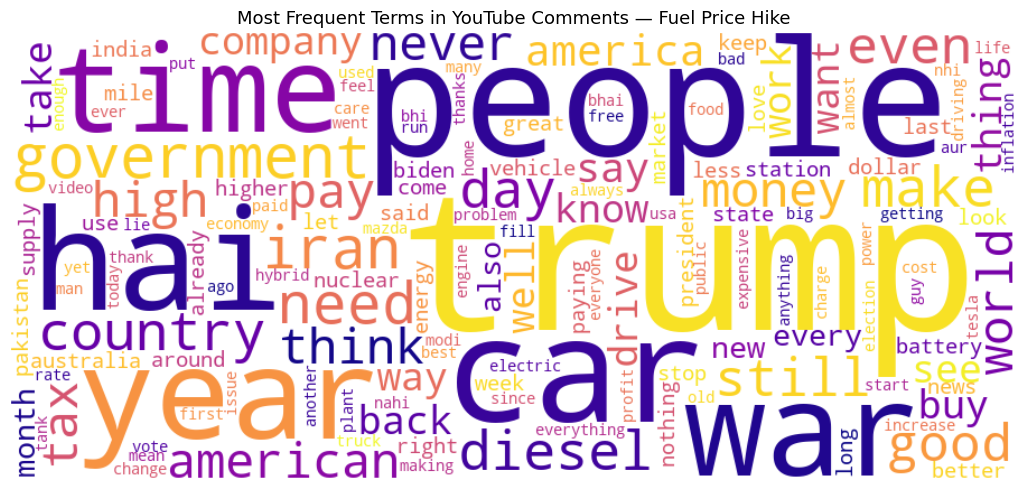

✅ Word cloud saved.


In [28]:
# ============================================================
# CELL 8 — Vocabulary Analysis
# Understand the most frequent terms before modelling.
# ============================================================
from wordcloud import WordCloud

# Flatten all tokens
all_tokens = [tok for tokens in comments_clean["text_tokens"] for tok in tokens]
token_freq = Counter(all_tokens)

print("Top 30 most frequent tokens:")
print(token_freq.most_common(30))

# Word cloud
wc = WordCloud(
    width=900, height=400,
    background_color="white",
    colormap="plasma",
    max_words=150
).generate_from_frequencies(token_freq)

plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Terms in YouTube Comments — Fuel Price Hike",
          fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/01_vocab_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word cloud saved.")

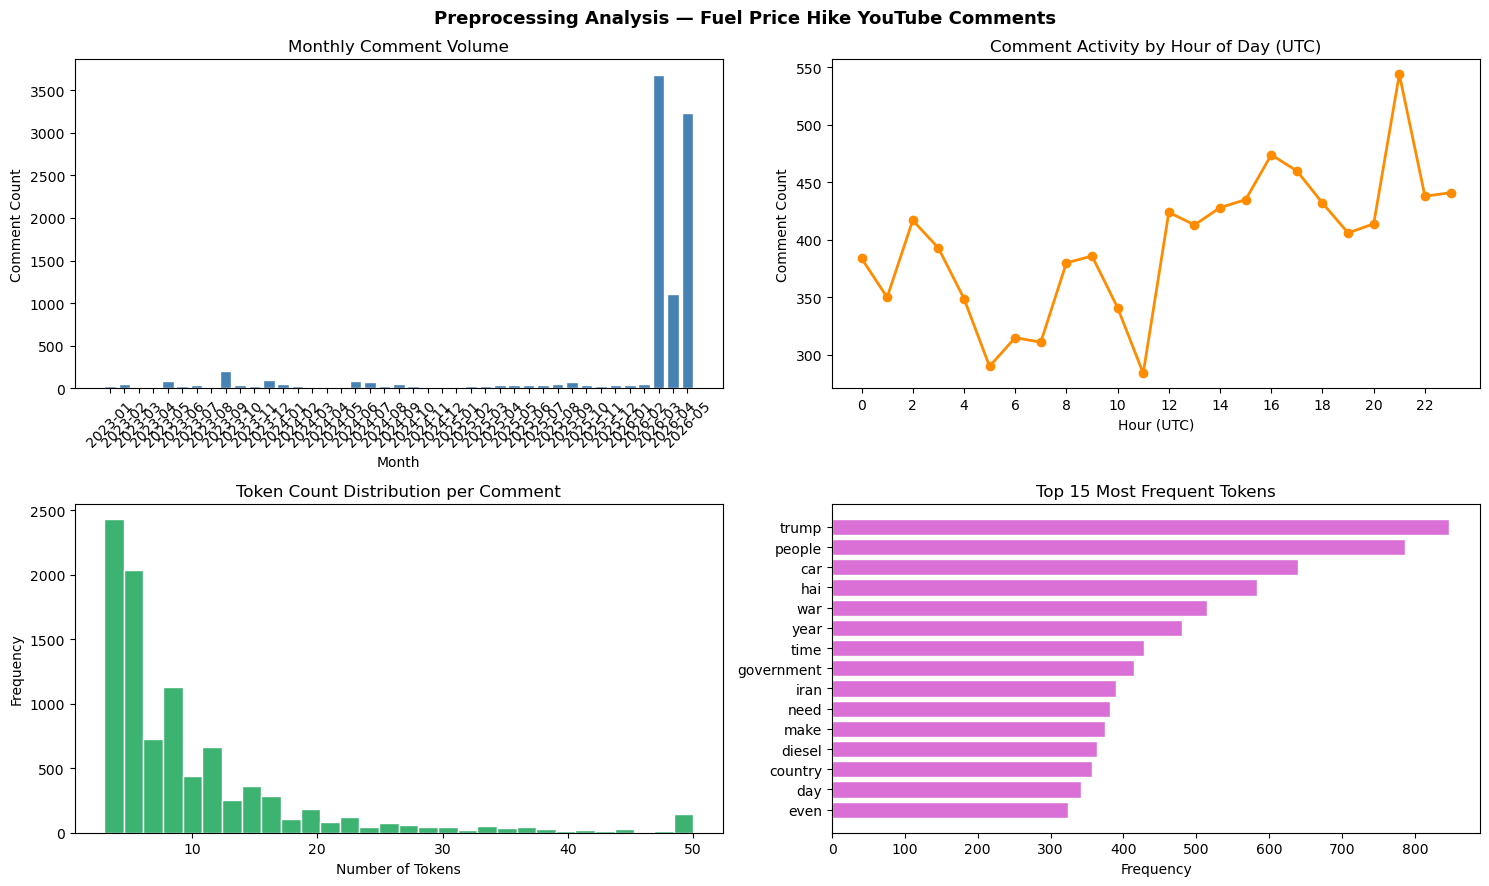

In [29]:
# ============================================================
# CELL 9 — Visualise Comment Activity Over Time
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# --- Monthly comment volume ---
monthly_comments = comments_clean.groupby("year_month").size()
axes[0, 0].bar(monthly_comments.index, monthly_comments.values,
               color="steelblue", edgecolor="white")
axes[0, 0].set_title("Monthly Comment Volume")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Comment Count")
axes[0, 0].tick_params(axis="x", rotation=45)

# --- Hour of day activity ---
hourly = comments_clean["hour"].value_counts().sort_index()
axes[0, 1].plot(hourly.index, hourly.values,
                color="darkorange", marker="o", linewidth=2)
axes[0, 1].set_title("Comment Activity by Hour of Day (UTC)")
axes[0, 1].set_xlabel("Hour (UTC)")
axes[0, 1].set_ylabel("Comment Count")
axes[0, 1].set_xticks(range(0, 24, 2))

# --- Token count distribution ---
axes[1, 0].hist(comments_clean["token_count"].clip(upper=50),
                bins=30, color="mediumseagreen", edgecolor="white")
axes[1, 0].set_title("Token Count Distribution per Comment")
axes[1, 0].set_xlabel("Number of Tokens")
axes[1, 0].set_ylabel("Frequency")

# --- Top 15 tokens bar chart ---
top15 = pd.DataFrame(token_freq.most_common(15),
                     columns=["token", "freq"])
axes[1, 1].barh(top15["token"], top15["freq"],
                color="orchid", edgecolor="white")
axes[1, 1].set_title("Top 15 Most Frequent Tokens")
axes[1, 1].set_xlabel("Frequency")
axes[1, 1].invert_yaxis()

plt.suptitle("Preprocessing Analysis — Fuel Price Hike YouTube Comments",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig('../outputs/02_preprocessing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ============================================================
# CELL 10 — Save All Preprocessed Files
# ============================================================
# Save processed videos
videos_df.to_csv('../data/videos_processed.csv', index=False)

# Save full comment set (for network — includes non-English)
comments_df.to_csv('../data/comments_processed.csv', index=False)

# Save NLP-ready comments (English, spam-filtered, with tokens)
# NOTE: token list stored as string — load with ast.literal_eval
comments_clean["text_tokens_str"] = comments_clean["text_tokens"].apply(str)
comments_clean.drop(columns=["text_tokens"]).to_csv(
    '../data/comments_nlp_ready.csv', index=False
)

print("✅ All preprocessed files saved:")
print("   data/videos_processed.csv      — cleaned videos with engagement scores")
print("   data/comments_processed.csv    — all comments (for network analysis)")
print("   data/comments_nlp_ready.csv    — English, spam-free, tokenised comments")
print(f"\nFinal counts:")
print(f"   Videos:           {len(videos_df)}")
print(f"   All comments:     {len(comments_df)}")
print(f"   NLP comments:     {len(comments_clean)}")

✅ All preprocessed files saved:
   data/videos_processed.csv      — cleaned videos with engagement scores
   data/comments_processed.csv    — all comments (for network analysis)
   data/comments_nlp_ready.csv    — English, spam-free, tokenised comments

Final counts:
   Videos:           212
   All comments:     11398
   NLP comments:     9509


In [33]:
# ============================================================
# CELL 11 — Preprocessing Summary Report
# Print key stats for your report's Data section.
# ============================================================
print("=" * 55)
print("PREPROCESSING SUMMARY — FOR REPORT")
print("=" * 55)

SEARCH_QUERIES = [
    "fuel price hike 2026",
    "petrol price increase 2026",
    "gas price spike reaction",
    "fuel cost crisis people reaction",
    "petrol price hike australia 2026",
    "oil price surge economy impact",
    "fuel prices too high opinion",
    "why is petrol so expensive 2026",
]

print(f"\nData Source:          YouTube Data API v3")
print(f"Collection Period:    {videos_df['published_at'].min().date()} "
      f"to {videos_df['published_at'].max().date()}")
print(f"Search Queries:       {len(SEARCH_QUERIES)}")
print(f"\nVideos:")
print(f"  Total collected:    {len(videos_df)}")
print(f"  Avg view count:     {videos_df['view_count'].mean():,.0f}")
print(f"  Avg like count:     {videos_df['like_count'].mean():,.0f}")
print(f"  Avg comment count:  {videos_df['comment_count'].mean():,.0f}")
print(f"\nComments:")
print(f"  Raw collected:      {len(comments_df)}")
print(f"  After dedup:        {len(comments_df)}")
print(f"  English only:       {comments_nlp['is_english'].sum()}")
print(f"  After spam filter:  {len(comments_clean)}")
print(f"  Unique authors:     {comments_clean['author_id'].nunique()}")
print(f"  Avg tokens/comment: {comments_clean['token_count'].mean():.1f}")
print(f"\nNetwork data ready:  {len(comments_df)} comments (all authors)")
print(f"NLP data ready:      {len(comments_clean)} comments (clean)")
print("=" * 55)

PREPROCESSING SUMMARY — FOR REPORT

Data Source:          YouTube Data API v3
Collection Period:    2023-01-02 to 2026-05-18
Search Queries:       8

Videos:
  Total collected:    212
  Avg view count:     227,616
  Avg like count:     7,623
  Avg comment count:  428

Comments:
  Raw collected:      11398
  After dedup:        11398
  English only:       10988
  After spam filter:  9509
  Unique authors:     8841
  Avg tokens/comment: 10.3

Network data ready:  11398 comments (all authors)
NLP data ready:      9509 comments (clean)
